> # SECTION -4

## Run quantum circuits

--- 
<h4>

- **Execution modes**

- Execution on real hardware

---

</h4>
REFERENCES: 

https://quantum.cloud.ibm.com/docs/en/guides/choose-execution-mode

https://quantum.cloud.ibm.com/docs/en/guides/execution-modes

> ## Execution modes

#### Provides :
#### - flexibility in balancing the cost 
#### - time tradeoff to use resources optimally for your workloads. 


Determine how your jobs are scheduled, and choosing the right execution mode allows your workload to run efficiently within your budget. 

> # Three execution modes: 
<h3>

  1. job

  2. session

  3. batch

  </h3>

> # 1. Job mode — best for a single experiment
<h3>
Job mode is the simplest option 

- Easy to use for small or indepedent  experiments like a single quantum computation.

- Workloads where execution does not depend on previous results.

- A job may sometimes start sooner than a batch.
</h3>

**Reccommendation :** Use job mode when submitting a single primitive request. 

**Use it when:** you have one small, independent quantum computation and don't need repeated interaction with the QPU.

> # 2. Batch mode — best default for multiple independent jobs

<h3>

Batch mode groups multiple jobs and schedules them together.

**Advantages:**

- The jobs don't each have to wait separately in the queue.
- Classical processing, such as compilation, can happen in parallel.
- Running jobs in batch mode is faster as compare to a single job execution in serial manner
- Allows related jobs to execute close together, thus miniumum delay between jobs , avoids drift.
- receive results from individual jobs and cancel or resubmit jobs independently.
- less expensive than session mode. 

</h3>

**Reccommendation :**

Use batch mode by default when your workload is made up of independent jobs whose inputs are available from the beginning. 

This way we can submit multiple primitive jobs simultaneously to shorten processing time.


**Use it when:** you have several independent circuits/experiments that can be prepared ahead of time.

-- Reconfigure the jobs for parallel processing



> # 3. Session mode — best for iterative workloads

<h4>

- Has batch mode functionality 

- Useful for workloads that don’t have all inputs ready at the outset,

- Provides dedicated/exclusive QPU access during the active session window

- user has exclusive access of the system and no other jobs can run - including calibration jobs

Designed for iterative quantum-classical workloads, where the result of one quantum execution influences what is executed next.
This is particularly important for algorithms in which a classical optimizer repeatedly interacts with a quantum processor.

</h4>
for example:

Run a circuit on the QPU.
Receive the result.
Perform classical optimization.
Modify circuit parameters.
Run another circuit.
Repeat.

Quantum circuit → measurement → classical optimization → updated circuit → quantum execution → repeat


### Without a session, each iteration may have to go back through the queue, significantly increasing total wall-clock time. A session keeps the workload tightly connected to the QPU and can reduce these delays. 

**TRADEOFF:** sessions generally cost more than batches. 

**Reccommendation :** useful when your workload is interactive or iterative, 

**Use it when:** your next quantum job depends on the result of the previous job, or when exclusive QPU access is important.

**Best suited for:**

- Variational Quantum Algorithms (VQAs).
- Quantum Approximate Optimization Algorithm (QAOA).
- Iterative parameter optimization.
- Workloads requiring frequent classical computation between quantum executions.

**Example 1 :** 
Run two VQE algorithms in a session by using threading.you can run two VQE algorithms, each using a different classical optimizer, simultaneously inside a single session

**Example 2:**
Run an iterative workload that uses the classical SciPy optimizer to minimize a cost function. In this model, SciPy uses the output of the cost function to calculate its next input


**Example 3:**
The QAOA optimization loop runs inside a Quantum Compute session to keep the device reserved across iterations. An Estimator evaluates <hc> at each step, and a classical optimizer (COBYLA) updates the parameters until convergence.



>## **Note:** 

> ## Open Plan users cannot submit session jobs
> ## Workloads on the Open Plan can run only in job mode or batch mode.

 > # "QPU time" : refers to time spent by the QPU complex to process your job.

> **Important performance guideline**

It is recommende to consider  the QPU time per job. 

**individual jobs < 1 minute**

it can be beneficial to combine several into a larger job because every job has some fixed overhead.


**individual jobs >  1 minute**

 If jobs are longer or cannot be combined, multiple jobs can still be run in parallel through batch or session execution. 

### <u>Choose based on the relationship between your jobs:</u>

<h4>

Independent → Batch

Iterative/dependent → Session

Single → Job
</h4>
In most cases, Batch should be your default choice. Move to Session when the algorithm needs rapid feedback between classical and quantum computation or dedicated QPU access.


> ### A simple way to select the execution mode: 

<h3>

**One computation** → Job

**Multiple independent computations** → Batch

**Multiple dependent/iterative computations** → Session
</h3>
In other words: Need to knpw how the workload is organized.

- If you have one thing to run, use Job.
- If you have many things to run independently, use Batch.
- If you need to run, analyze, modify, and run again, use Session.

# REFERENCES : 

https://quantum.cloud.ibm.com/docs/en/guides/run-jobs-batch

https://quantum.cloud.ibm.com/docs/en/guides/run-jobs-session

https://quantum.cloud.ibm.com/docs/en/tutorials/quantum-approximate-optimization-algorithm

># To Set up to use batch / sessions

 #### Need to **set up the IBM Quantum Compute client** 

 from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Session,
    Bztch
    SamplerV2 as Sampler,
    EstimatorV2 as Estimator,
)
#### initialize it as a service:
service = QiskitRuntimeService()  

> # Open a Batch/session 
<h3>

1. open a runtime batch by using the **context manager** 

For batch :  with Batch(...)  </br>
For batch :  with Session(...) 

OR

2. Intialization ----->

 **Batch class**

 batch=Batch(backend=backend)

 **Session class**

 session = Session(backend=backend)


</h3>
NOTE: 

- ### When you start a batch/session , you must specify a QPU by passing a backend object. 
- ### The batch/session starts when its first job begins execution.
- ### In batch/session class, we need to "Close" the batch when no context manager used
- ### The context manager automatically opens and closes the batch/session.

> # batch/session  details 

#### overview of configuration and status, 
- use the batch.details() method

- use the session.details() method

 > # batch/session  length
 
 #### <u>Define the batch's maximum time to live (TTL) with the max_time parameter</u>

 with Batch(backend=backend, max_time="25m"):

 #### <u>The maximum session time to live (TTL) determines how long a session can run</u>

 with Session(backend=backend, max_time="25m"):

># Check session status

### query a session's status to understand its current state by using **session.status()**

---

> # Example:Batch mode
---

https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/batch#batch

In [1]:
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

# using the fake backend 
backend = FakeManilaV2()

In [2]:
backend.backend_name

'fake_manila'

n_local:
https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.n_local

-     alternating rotation and entanglement layers

 In both layers, parameterized circuit-blocks act on the circuit in a defined way. In the rotation layer, the blocks are applied stacked on top of each other, while in the entanglement layer according to the entanglement strategy. 
 
 Each layer is repeated reps times, and by default a final rotation layer is appended.

In [3]:
from qiskit.circuit.library import n_local
import numpy as np
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import Batch
from qiskit_ibm_runtime import SamplerV2 as Sampler



# entanglement type is linear 
circuit1= n_local(
    num_qubits=3,
    rotation_blocks='rx',
    entanglement_blocks='cx',
    entanglement='linear',
    reps=3   # number of alternating layers
)

param_values1 = np.random.rand(circuit1.num_parameters)

bound_circuit1 = circuit1.assign_parameters(param_values1)


# entanglement type is circular 
circuit2= n_local(
    num_qubits=3,
    rotation_blocks='ry',
    entanglement_blocks='cx',
    entanglement= "circular",
    reps=3  # number of alternating layers
)


param_values2 = np.random.rand(circuit2.num_parameters)

bound_circuit2= circuit2.assign_parameters(param_values2)

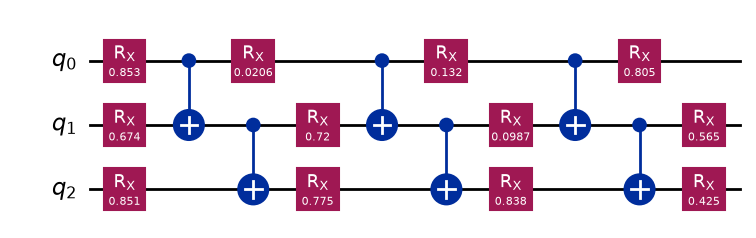

In [4]:
bound_circuit1.draw("mpl")

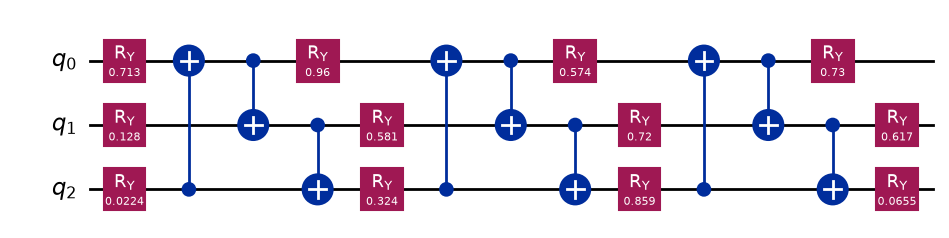

In [5]:
bound_circuit2.draw("mpl")

In [6]:
bound_circuit1.measure_all()

bound_circuit2.measure_all()


pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

isa_circuit1 = pm.run(bound_circuit1)

isa_circuit2 = pm.run(bound_circuit2)

# The context manager automatically closes the batch.
with Batch(backend=backend) as batch:
    sampler = Sampler(mode=batch)

    job1 = sampler.run([isa_circuit1 ])

    job2 = sampler.run([isa_circuit2 ])

    result1 = job1.result()
    result2 = job2.result()


In [7]:

# first job

print(
    f" > The first five measurement results of job 1: "
    f"{result1[0].data.meas.get_bitstrings()[:5]}"
)

 > The first five measurement results of job 1: ['010', '100', '110', '100', '100']


In [8]:
# second job
print(
    " > The first five measurement results of job 2:",
    result2[0].data.meas.get_bitstrings()[:5],
)

 > The first five measurement results of job 2: ['100', '010', '011', '011', '100']
